In [3]:
import os 
import cv2
import glob
import json
import torch
import torch.nn as nn
import torch.nn.functional as F

import einops
import random
import argparse
import numpy as np
import matplotlib.pyplot as plt

os.chdir('/root/autodl-tmp/omniHand')

from easydict import EasyDict as edict
from deepspeed.utils.zero_to_fp32 import load_state_dict_from_zero_checkpoint

torch.set_float32_matmul_precision('high')
torch.autograd.set_detect_anomaly(True)

from src.utils.io import load_yaml
from src.utils.tools import instantiate_from_config
from src.utils.plot import plot_hand_camera, plot_hand_subplot
import warnings
warnings.filterwarnings("ignore", message="The dataloader, train_dataloader, does not have many workers", category=UserWarning)
warnings.filterwarnings("ignore", message="The dataloader, val_dataloader, does not have many workers", category=UserWarning)

In [4]:
args = edict({
    'config': 'config/omnihand_large_daily.yaml',
    'world_size': 1,
    'rank': 0,
    'seed': 42,
    'resume_checkpoint': 'log/omnihand/omnihand-large-daily-0525/last.ckpt',
})
cfg = load_yaml(args.config)

device = 'cuda'

# load data 
data_cfg = cfg.data_cfg
data_cfg.params.cfg.batch_size = 1
# data_cfg.params.cfg.val_split = 'dataset/csl-daily/val.json'
data = instantiate_from_config(data_cfg)
data.setup('fit')

# # set seed 
# set_seed(seed=args.seed, n_gpu=args.world_size)

# load model 
model_cfg = cfg.model_cfg
model_cfg.params.cfg.batch_size = 1
model = instantiate_from_config(model_cfg)
# Load checkpoint using the function provided by DeepSpeed
load_state_dict_from_zero_checkpoint(model, args.resume_checkpoint)
# Replace all occurrences of 'global_cubenet.' with 'global_backbone.' in the state_dict keys
model = model.to(device).eval()
print('model loaded.')

[2025-05-25 11:39:54,414] [INFO] [zero_to_fp32.py:712:load_state_dict_from_zero_checkpoint] Extracting fp32 weights
Processing zero checkpoint 'log/omnihand/omnihand-large-daily-0525/last.ckpt/checkpoint'


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 915.39it/s]

Detected checkpoint of type zero stage 2, world_size: 2


Parsing checkpoint created by deepspeed==0.16.7
Reconstructed fp32 state dict with 220 params 495083152 elements
[2025-05-25 11:39:55,800] [INFO] [zero_to_fp32.py:715:load_state_dict_from_zero_checkpoint] Overwriting model with fp32 weights
model loaded.


In [5]:
def process_batch(batch, model, device='cuda'):
    """Process a batch of data through the model
    
    Args:
        batch: Dictionary containing input data
        model: OmniHand model instance
        device: Device to run on
        
    Returns:
        Dictionary containing processed joint points
    """
    # Move data to device and handle numpy arrays
    for key in batch:
        if isinstance(batch[key], np.ndarray):
            batch[key] = torch.tensor(batch[key]).unsqueeze(0).to(device)
        elif isinstance(batch[key], torch.Tensor):
            batch[key] = batch[key].unsqueeze(0).to(device)

    # Forward pass
    if data_cfg.params.cfg.opt.load_feature:
        features = batch['features']
    else:
        features = model.encode_feature(batch['joints'], batch['velocities'])
    joints = batch['joints']
    joints_pred = model.forward_feature(features)

    # Calculate and print MPJPE
    valid_mask = ~torch.isnan(joints)
    joints_pred_ = joints_pred[valid_mask].reshape(-1, 3)   
    joints_ = joints[valid_mask].reshape(-1, 3)
    mpjpe = torch.norm(joints_pred_ - joints_, dim=-1).mean() * 1e3
    print(f'MPJPE: {mpjpe:.2f}')

    def get_points(joints):
        points = joints[0].cpu().detach().numpy() * 1e3
        return points

    # Process left and right hands separately
    joints_l, joints_r = joints[:, 0], joints[:, 1]
    joints_pred_l, joints_pred_r = joints_pred[:, 0], joints_pred[:, 1]
    
    # Transform coordinates
    joints_points_l = get_points(joints_l)
    joints_points_r = get_points(joints_r)
    joints_pred_points_l = get_points(joints_pred_l)
    joints_pred_points_r = get_points(joints_pred_r)
    
    return {
        'joints_points_l': joints_points_l,
        'joints_points_r': joints_points_r,
        'joints_pred_points_l': joints_pred_points_l,
        'joints_pred_points_r': joints_pred_points_r,
        'mpjpe': mpjpe.item()
    }

MPJPE: 24.44


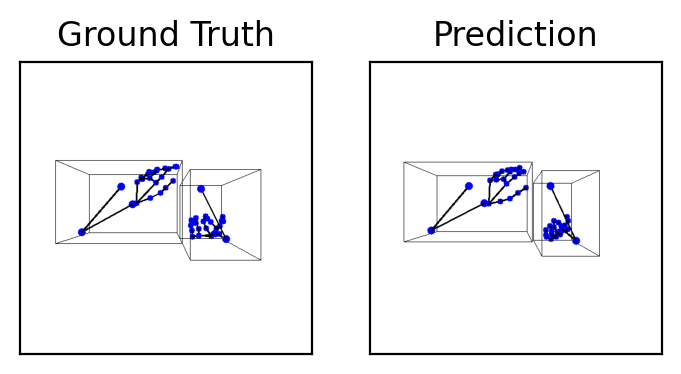

In [12]:
camera_params = {
    'camera_position': [0, 0, -1000],
    'camera_intrinsic': [800, 800, 256.0, 256.0]
}

batch = random.choice(data.val_dataset)
results = process_batch(batch, model, device)

plt.figure(dpi=200)
plot_hand_subplot(131, camera_params, results['joints_points_l'], results['joints_points_r'], 'Ground Truth')
plot_hand_subplot(132, camera_params, results['joints_pred_points_l'], results['joints_pred_points_r'], 'Prediction')
plt.show()